In [1]:
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from numba import jit
import os
from tqdm import tqdm

In [2]:
# poly_params = [N, m ,Re]
@jit(nopython=True)
def hamiltonian(r, kB, T, poly_params):
    N = poly_params[0]
    m = poly_params[1]
    Re = poly_params[2]

    harmonic_contribution = 0
    for segment in range(1, N):
        harmonic_contribution += np.sum((r[segment]-r[segment-1])**2)

    harmonic_contribution *= 3*(N-1)/(2*Re**2)

    return harmonic_contribution

def end_theory(R, Re):
    return (4*np.pi*R**2)*(3/(2*np.pi*Re**2))**1.5 * np.exp(-3*R**2/(2*Re**2))

def plotter(r, step):
    fig = plt.figure(figsize=(4, 3))
    ax = fig.add_subplot(111, projection='3d')
    
    # colors = cm.viridis(np.linspace(0, 1, len(r)))
    for i in range(len(r) - 1):
        ax.plot(r[i:i+2, 0], r[i:i+2, 1], r[i:i+2, 2], color="k")
    ax.plot([r[0, 0]], [r[0, 1]], [r[0, 2]], 'o', color="r", markersize=6)
    ax.plot([r[-1, 0]], [r[-1, 1]], [r[-1, 2]], '*', color="blue", markersize=6)

    ax.grid(False)
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    fig.suptitle(f"Step {step}")
    fig.tight_layout()

    output_filepath = f"data/imgs/mcmc/evolution/"
    output_filename = f"step_{step}.png"
    
    if not os.path.exists(output_filepath):
        os.makedirs(output_filepath)
    file = os.path.join(output_filepath, output_filename)

    plt.savefig(file, dpi=50)
    plt.close()

In [3]:
# constants
kB=1 # Boltzmann constant

# Simulation box
dims=3 # dimensions of simulation

# Thermodynamic params
T=1 # Temperature

# Polymer
N=10 # segments
m=1 # mass of each monomer
Re=1 # end-to-end distance

# Monte Carlo params
N_steps_list=[100, 1000, 10000, 100000]
delta=2*Re/np.sqrt(N-1)


In [4]:
# # initialize initial configuration randomly from a normal distribution
# r = np.zeros((N, dims))

# for segment in range(1, N):
#     r[segment] = r[segment-1] + np.random.normal(0, 1, dims)

# fig = plt.figure(figsize=(4, 3))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(r[:, 0], r[:, 1], r[:, 2], '-o', markersize=3)
# ax.plot(r[0:1, 0], r[0:1, 1], r[0:1, 2], '-s', color="k", markersize=5)

# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")
# fig.suptitle(f"Step {0}")
# fig.tight_layout()

In [5]:
R_per_N_steps = []
# mc loop
for N_steps in N_steps_list:
    r = np.zeros((N, dims))
    for segment in range(1, N):
        r[segment] = r[segment - 1] + np.random.normal(0, 1, dims)
    
    H_current = hamiltonian(r, kB, T, [N, m, Re])
    
    R = []  # Store end-to-end distances

    for step in tqdm(range(N_steps)):
        for segment in range(N):
            old_pos = r[segment].copy()
    
            r[segment] += np.random.uniform(-delta, delta, 3)
    
            H_proposal = hamiltonian(r, kB, T, [N, m, Re])
            H_delta = H_proposal - H_current
    
            if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB * T)):
                H_current = H_proposal
            else:
                r[segment] = old_pos
    
        # plotter(r, step)    
        R.append(np.linalg.norm(r[-1]-r[0]))
    R_per_N_steps.append(R)

100%|█████████████████████████████████████| 100000/100000 [00:06<00:00, 14637.44it/s]


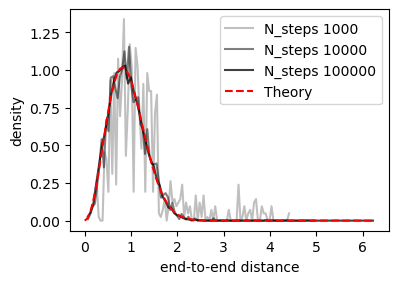

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
for idx, N_steps in enumerate(N_steps_list):
    if idx==0:
        continue
    counts, bins = np.histogram(R_per_N_steps[idx], bins=100, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax.plot(bin_centers, counts, color="k", alpha=idx/len(N_steps_list), label=f"N_steps {N_steps}")
ax.plot(np.linspace(0, np.max(R_per_N_steps[-1]), 100), end_theory(np.linspace(0, np.max(R_per_N_steps[-1]), 100), Re), "--", label="Theory", color="r")
ax.legend(loc = "upper right")
ax.set_xlabel("end-to-end distance")
ax.set_ylabel("density")
fig.tight_layout()

In [7]:
r = np.zeros((N, dims))
for segment in range(1, N):
    r[segment] = r[segment - 1] + np.random.normal(0, 1, dims)

H_current = hamiltonian(r, kB, T, [N, m, Re])

R_mag = []  # Store end-to-end distances magnitude
R_vecs = []

q_vals = np.logspace(-2, 2, 25)
ndir = 15  # number of random directions per q

S_q_accum = np.zeros(len(q_vals), dtype=np.float64)
N_snapshots = 0

rouse_positions = []

for step in tqdm(range(N_steps_list[-1])):
    for segment in range(N):
        old_pos = r[segment].copy()

        r[segment] += np.random.uniform(-delta, delta, 3)

        H_proposal = hamiltonian(r, kB, T, [N, m, Re])
        H_delta = H_proposal - H_current

        if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB * T)):
            H_current = H_proposal
        else:
            r[segment] = old_pos
    rouse_positions.append(r.copy())
    
    # plotter(r, step)    
    R_mag.append(np.linalg.norm(r[-1]-r[0]))
    R_vecs.append(r[-1]-r[0])
    for iq, q in enumerate(q_vals):
        S_temp = 0
        for _ in range(ndir):
            u = np.random.normal(size=3)
            u /= np.linalg.norm(u)
            qr = q * r.dot(u)  # shape (N,)
            S_temp += np.abs(np.sum(np.exp(1j * qr)))**2
        S_q_accum[iq] += S_temp / (ndir * N)
    N_snapshots += 1

S_q = S_q_accum / N_snapshots


100%|███████████████████████████████████████| 100000/100000 [04:36<00:00, 361.01it/s]


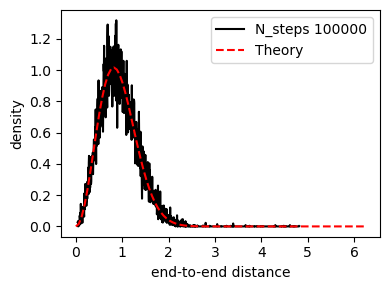

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
counts, bins = np.histogram(R_mag, bins=1000, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
ax.plot(bin_centers, counts, color="k", label=f"N_steps {N_steps}")
ax.plot(np.linspace(0, np.max(R_per_N_steps[-1]), 100), end_theory(np.linspace(0, np.max(R_per_N_steps[-1]), 100), Re), "--", label="Theory", color="r")
ax.legend(loc = "upper right")
ax.set_xlabel("end-to-end distance")
ax.set_ylabel("density")
fig.tight_layout()

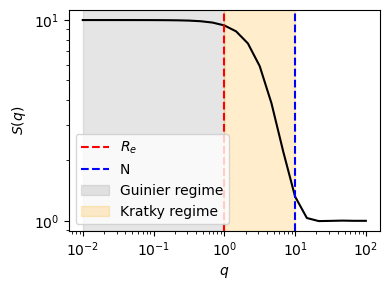

In [9]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.loglog(q_vals, S_q, color="k")
ax.axvline(Re, color="r", linestyle="--", label=r"$R_e$")
ax.axvline((N), color="b", linestyle="--", label=r"N")
ax.axvspan(q_vals[0], Re, color='grey', alpha=0.2, label="Guinier regime")
ax.axvspan(Re, N, color='orange', alpha=0.2, label="Kratky regime")

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$S(q)$')

ax.legend(loc="lower left")
fig.tight_layout()


In [10]:
R_vecs=np.asarray(R_vecs)

T = len(R_vecs)
Re2 = np.mean(np.sum(R_vecs**2, axis=1))
C = np.zeros(T)

for dt in tqdm(range(T)):
    C[dt] = np.einsum('ij,ij->i', R_vecs[:T-dt], R_vecs[dt:]).mean()

C /= Re2

max_lag = T // 10
C_R_truncated = C[:max_lag]

100%|██████████████████████████████████████| 100000/100000 [00:16<00:00, 6177.00it/s]


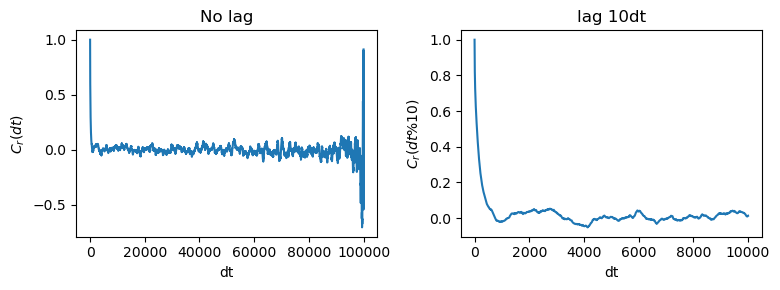

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].plot(range(T), C)
ax[0].set_xlabel("dt")
ax[0].set_ylabel(r"$C_r(dt)$")
ax[0].set_title("No lag")


ax[1].plot(np.arange(max_lag), C_R_truncated)
ax[1].set_xlabel("dt")
ax[1].set_ylabel(r"$C_r(dt\%10)$")
ax[1].set_title("lag 10dt")

fig.tight_layout()

In [12]:
X1 = []
for p in rouse_positions:
    s = 0
    for i in range(N):
        s += (p[i]/Re) * np.cos((np.pi/N) * (i-0.5)) 
    X1.append(s/N)

In [13]:
X1

[array([-0.22168226,  0.40403967,  0.11383885]),
 array([-0.18317319,  0.41560302,  0.08155216]),
 array([-0.24354198,  0.49324996,  0.07030168]),
 array([-0.27597744,  0.42997864,  0.10693641]),
 array([-0.3193311 ,  0.4826572 ,  0.15669965]),
 array([-0.24577294,  0.50959967,  0.1833869 ]),
 array([-0.23013829,  0.5089933 ,  0.10218117]),
 array([-0.20315557,  0.4549887 ,  0.06446183]),
 array([-0.12569985,  0.40767119,  0.05186602]),
 array([-0.15585756,  0.37677946,  0.06769492]),
 array([-0.20490037,  0.39239259,  0.05126785]),
 array([-0.21852869,  0.42131248,  0.0734176 ]),
 array([-0.21852869,  0.42131248,  0.0734176 ]),
 array([-0.24029095,  0.4473005 ,  0.01881128]),
 array([-0.27227482,  0.49875528, -0.03608284]),
 array([-0.21131866,  0.47539148, -0.07367607]),
 array([-0.20831654,  0.47414505,  0.0354459 ]),
 array([-0.20555298,  0.48267213,  0.03199566]),
 array([-0.23329485,  0.48199632,  0.04146378]),
 array([-0.23972616,  0.47066082,  0.05157149]),
 array([-0.19720153,

In [14]:
X1 = np.array(X1)
mean_X1 = X1.mean(axis=0)       
var_X1  = (X1**2).mean(axis=0)   

print(mean_X1, var_X1)

[ 0.15062075 -0.8003126   0.36443736] [0.15826753 0.81152947 0.51642804]


In [15]:
X1_vecs=np.asarray(X1)

T = len(X1_vecs)
X12 = np.mean(np.sum(X1_vecs**2, axis=1))
C_X = np.zeros(T)

for dt in tqdm(range(T)):
    C_X[dt] = np.einsum('ij,ij->i', X1_vecs[:T-dt], X1_vecs[dt:]).mean()

C_X /= X12

max_lag = T // 10
C_X_truncated = C_X[:max_lag]

100%|██████████████████████████████████████| 100000/100000 [00:16<00:00, 6055.40it/s]


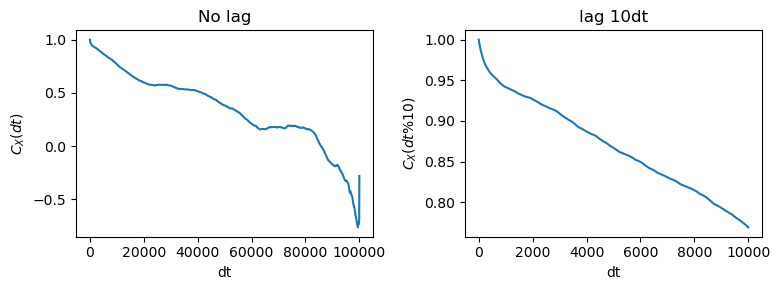

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].plot(range(T), C_X)
# ax[0].loglog(range(T), C_X)
ax[0].set_xlabel("dt")
ax[0].set_ylabel(r"$C_X(dt)$")
ax[0].set_title("No lag")


ax[1].plot(np.arange(max_lag), C_X_truncated)
# ax[1].loglog(np.arange(max_lag), C_X_truncated)
ax[1].set_xlabel("dt")
ax[1].set_ylabel(r"$C_X(dt\%10)$")
ax[1].set_title("lag 10dt")

fig.tight_layout()